# Proyek Analisis Data: [Kualitas Udara]
- **Nama:** Fadhilah Hafidz Haditama
- **Email:** mc001d5x1730@student.devacademy.id
- **ID Dicoding:** MC001D5X1730

## Menentukan Pertanyaan Bisnis

- Bagaimana pola bulanan polutan PM2.5, PM 10, dan O3 di wilayah urban (Wanshouxigong), suburban (Changping), dan rural (Huariou)?
- Bagaimana pola diurnal polutan PM2.5, PM10, dan O3 di wilayah urban (Wanshouxigong), suburban (Changping), dan rural (Huariou)?
- Apakah konsentrasi polutan PM2.5 dan PM10 di atas BMUA harian (24 jam) untuk wilayah urban (Wanshouxigong), suburban (Changping), dan rural (Huariou)?
- Bagaimana kategori data rata-rata bulanan di wilayah urban (Wanshouxigong), suburban (Changping), dan rural (Huariou)?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Set working directory
from google.colab import files
uploaded = files.upload()

Saving PRSA_Data_Changping_20130301-20170228.csv to PRSA_Data_Changping_20130301-20170228 (2).csv
Saving PRSA_Data_Huairou_20130301-20170228.csv to PRSA_Data_Huairou_20130301-20170228 (2).csv
Saving PRSA_Data_Wanshouxigong_20130301-20170228.csv to PRSA_Data_Wanshouxigong_20130301-20170228 (2).csv


In [ ]:
# Load data
df = pd.concat([pd.read_csv(file, delimiter=',') for file in uploaded], ignore_index=True)
print(df.head())

   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    3.0   6.0  13.0   7.0  300.0  85.0  -2.3   
1   2  2013      3    1     1    3.0   3.0   6.0   6.0  300.0  85.0  -2.5   
2   3  2013      3    1     2    3.0   3.0  22.0  13.0  400.0  74.0  -3.0   
3   4  2013      3    1     3    3.0   6.0  12.0   8.0  300.0  81.0  -3.6   
4   5  2013      3    1     4    3.0   3.0  14.0   8.0  300.0  81.0  -3.5   

     PRES  DEWP  RAIN   wd  WSPM    station  
0  1020.8 -19.7   0.0    E   0.5  Changping  
1  1021.3 -19.0   0.0  ENE   0.7  Changping  
2  1021.3 -19.9   0.0  ENE   0.2  Changping  
3  1021.8 -19.1   0.0  NNE   1.0  Changping  
4  1022.3 -19.4   0.0    N   2.1  Changping  


In [ ]:
# Ambil data, buang yang tidak perlu, buat urutan kolom baru
df = df.drop(['No','TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM','SO2', 'NO2','CO'], axis=1)
new_order = ["station"] + ["year"] + ["month"] + ["day"] + ["hour"] + [col for col in df if col != "year" and col != "month" and col != "day" and col != "hour" and col != "station"]
df = df[new_order]
print(df.head())
print(df.tail())

     station  year  month  day  hour  PM2.5  PM10    O3
0  Changping  2013      3    1     0    3.0   6.0  85.0
1  Changping  2013      3    1     1    3.0   3.0  85.0
2  Changping  2013      3    1     2    3.0   3.0  74.0
3  Changping  2013      3    1     3    3.0   6.0  81.0
4  Changping  2013      3    1     4    3.0   3.0  81.0
              station  year  month  day  hour  PM2.5  PM10    O3
105187  Wanshouxigong  2017      2   28    19   11.0  32.0  72.0
105188  Wanshouxigong  2017      2   28    20   13.0  32.0  50.0
105189  Wanshouxigong  2017      2   28    21   14.0  28.0  54.0
105190  Wanshouxigong  2017      2   28    22   12.0  23.0  59.0
105191  Wanshouxigong  2017      2   28    23   13.0  19.0  49.0


**Insight:**
- Pengambilan dataset Air-Quality-Dataset dari dataset dicoding
- Pengambilan waktu dan data konsentrasi polutan PM2.5, PM10, dan O3 saja
- Pembuangan kolom parameter kondisi cuaca

### Assessing Data

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105192 entries, 0 to 105191
Data columns (total 8 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   station  105192 non-null  object 
 1   year     105192 non-null  int64  
 2   month    105192 non-null  int64  
 3   day      105192 non-null  int64  
 4   hour     105192 non-null  int64  
 5   PM2.5    102769 non-null  float64
 6   PM10     103349 non-null  float64
 7   O3       102359 non-null  float64
dtypes: float64(3), int64(4), object(1)
memory usage: 6.4+ MB
None
station       0
year          0
month         0
day           0
hour          0
PM2.5      2423
PM10       1843
O3         2833
dtype: int64
          station           year         month            day           hour  \
count      105192  105192.000000  105192.00000  105192.000000  105192.000000   
unique          3            NaN           NaN            NaN            NaN   
top     Changping            NaN           NaN    

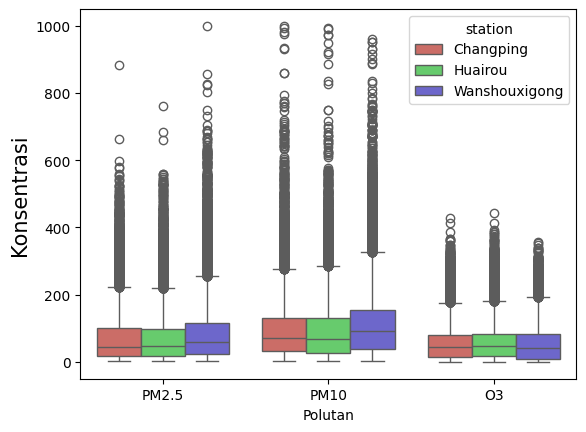

In [ ]:
#cek data duplikat
print(df.duplicated().sum())

#cek data
print(df.info())

#cek data kosong
print(df.isnull().sum())

#cek statistik data
print(df.describe(include='all'))

#cek sebaran data pencilan PM2.5, PM10, O3 dengan boxplot
df_melted = df.melt(id_vars='station', value_vars=['PM2.5', 'PM10','O3'],
                    var_name='Polutan', value_name='Konsentrasi')

sns.boxplot(x='Polutan', y='Konsentrasi',data=df_melted, hue='station', palette="hls")
plt.ylabel('Konsentrasi',size=15)
plt.show()

**Insight:**
- Tidak ada data duplikat
- Terdapat missing value di PM2.5, PM10, dan O3
- Data min rendah dan max sangat jauh dari nilai normal aktualnya
- Terlalu banyak pencilan atas dan sedikit pencilan bawah untuk semua jenis polutan dalam waktu jam an

### Cleaning Data

In [ ]:
#karena missing value dibawah 20% (standar kebutuhan data pencemaran udara) dari total data maka drop baris NA
df = df.dropna()

#memastikan nilai null
print(df.isnull().sum())

station    0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
O3         0
dtype: int64


In [ ]:
#ambil data yang memiliki pencilan
kolom_polutan = df[["PM2.5", "PM10", "O3"]]

'''Ganti data pencilan. Nilai pencilan atas menjadi max normal dan pencilan bawah menjadi min normal.
Argumen ini didukung kemungkinan data dengan nilai diluar normal menandakan kondisi aktual yang memang ekstrem
(wajar untuk wilayah dengan banyak anomali seperti industrial), namun terlalu tinggi bahkan untuk nilai ekstrem, ex: PM10 999 μg/m³ tiap jam'''

for colomns in kolom_polutan:
  for station, group in df.groupby('station'):
    #membuat nilai kuartil berdasarkan masing-masing jenis polutan di masing-masing stasiun
    Q1 = group[colomns].quantile(0.25)
    Q3 = group[colomns].quantile(0.75)
    #membuat nilai jangkauan berdasarkan masing-masing jenis polutan di masing-masing stasiun
    IQR = Q3 - Q1
    #batas atas dan batas bawah sebaran normal
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    #kondisi pencilan
    lower_than = df[colomns] < lower_bound
    upper_than = df[colomns] > upper_bound
    #ganti data pencilan
    df[colomns] = df[colomns].mask(cond=lower_than, other=lower_bound)
    df[colomns] = df[colomns].mask(cond=upper_than, other=upper_bound)
#melihat statistik data setelah cleaning pencilan
df.describe()

,year,month,day,hour,PM2.5,PM10,O3
count,101358.000000,101358.000000,101358.000000,101358.000000,101358.000000,101358.000000,101358.000000
mean,2014.674865,6.516338,15.712021,11.516476,70.648624,95.187244,55.521931
std,1.178623,3.457565,8.784991,6.928292,62.944230,74.725886,48.631230
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.214200
25%,2014.000000,4.000000,8.000000,6.000000,19.000000,33.000000,13.000000
50%,2015.000000,7.000000,16.000000,12.000000,51.000000,77.000000,46.000000
75%,2016.000000,10.000000,23.000000,18.000000,105.000000,138.000000,81.000000
max,2017.000000,12.000000,31.000000,23.000000,219.500000,275.500000,175.000000


In [ ]:
#Persentase data set setelah cleaning
for colomns in kolom_polutan:
  persentase = df[colomns].count() / 105192 * 100
  print(f"Persentase data {colomns} setelah cleaning: {persentase:.2f}%")

Persentase data PM2.5 setelah cleaning: 96.36%
Persentase data PM10 setelah cleaning: 96.36%
Persentase data O3 setelah cleaning: 96.36%


**Insight:**
- Data PM2.5, PM10, O3 cukup tinggi dan wajar untuk di wilayah perkotaan Beijing
- Persentase jumlah data setelah proses cleaning di atas 80%, sehingga cukup dalam penilaian konsentrasi polutan

## Exploratory Data Analysis (EDA)

### Explore nilai statistik per stasiun tiap polutan

In [ ]:
#lihat data statistik berdasarkan group stasiun dan polutan
df.groupby("station").agg({
    'PM2.5': ['mean', 'median', 'min', 'max', 'std'],
    'PM10': ['mean', 'median', 'min', 'max', 'std'],
    'O3': ['mean', 'median', 'min', 'max', 'std']
})

PM2.5                                      PM10         \
                    mean median  min    max        std        mean median   
station                                                                     
Changping      67.712689   46.0  2.0  219.5  61.732805   91.376417   72.0   
Huairou        66.503289   47.0  2.0  219.5  60.913674   88.723283   69.0   
Wanshouxigong  77.759216   59.0  3.0  219.5  65.496112  105.498001   90.0   

                                             O3                        \
               min    max        std       mean median     min    max   
station                                                                 
Changping      2.0  275.5  71.938143  55.399441   46.0  0.2142  175.0   
Huairou        2.0  275.5  72.909802  57.260494   49.0  0.2142  175.0   
Wanshouxigong  2.0  275.5  78.123141  53.910774   42.0  0.2142  175.0   

                          
                     std  
station                   
Changping      47.497813  
Huairou        47.295065  
Wanshouxigong  50.968367

### Explore Konsentrasi polutan dalam bulanan

In [ ]:
#konsentrasi rata-rata bulanan
Pola_bulanan = df.groupby(['station', 'month']).agg({
    'PM2.5': ['mean'],
    'PM10': ['mean'],
    'O3': ['mean']
})
Pola_bulanan = Pola_bulanan.reset_index()

#flattering nilai hierarki agg
Pola_bulanan.columns = ['station', 'month', 'PM2.5', 'PM10', 'O3']
print(Pola_bulanan)

#melt data untuk mempermudah visualisasi catplot
visualisasi_bulanan = Pola_bulanan.melt(id_vars=['station', 'month'],
                                        value_vars=['PM2.5', 'PM10', 'O3'],
                                        var_name='Polutan', value_name='Konsentrasi')

#lihat data untuk visualisasi diurnal
print(visualisasi_bulanan)

          station  month      PM2.5        PM10         O3
0       Changping      1  76.940800   98.862483  27.465561
1       Changping      2  72.685963   91.101211  37.406735
2       Changping      3  79.206796  123.432650  50.342634
3       Changping      4  68.518565  105.686013  70.022817
4       Changping      5  59.437170   94.731244  86.900801
5       Changping      6  58.907684   75.717589  90.271656
6       Changping      7  63.391457   73.490021  89.271314
7       Changping      8  46.724345   62.789867  86.154716
8       Changping      9  54.964184   67.840426  57.617393
9       Changping     10  76.868134   98.473809  29.118487
10      Changping     11  76.029748  101.323055  19.542092
11      Changping     12  79.087615  102.304866  20.320209
12        Huairou      1  74.029412   88.895246  27.831053
13        Huairou      2  72.868652   86.272032  43.405109
14        Huairou      3  82.698787  116.073042  56.037560
15        Huairou      4  66.883650  105.345823  74.4594

In [ ]:
#simpan file dalam bentuk csv
visualisasi_bulanan.to_csv('visualisasi_bulanan.csv', index=False)

### Explore Konsentrasi polutan dalam jam

In [ ]:
#konsentrasi rata-rata diurnal
Pola_diurnal = df.groupby(['station', 'hour']).agg({
    'PM2.5': ['mean'],
    'PM10': ['mean'],
    'O3': ['mean']
})
Pola_diurnal = Pola_diurnal.reset_index()

#flattering nilai hierarki agg
Pola_diurnal.columns = ['station', 'hour', 'PM2.5', 'PM10', 'O3']

#lihat hasil flattering
print(Pola_diurnal)

#melt data untuk mempermudah visualisasi catplot
visualisasi_diurnal = Pola_diurnal.melt(id_vars=['station', 'hour'],
                                        value_vars=['PM2.5', 'PM10', 'O3'],
                                        var_name='Polutan', value_name='Konsentrasi')
#lihat data untuk visualisasi diurnal
print(visualisasi_diurnal)


          station  hour      PM2.5        PM10         O3
0       Changping     0  68.875350   89.049020  47.901412
1       Changping     1  67.668417   86.069328  43.139680
2       Changping     2  65.963776   83.177203  38.148395
3       Changping     3  64.944292   80.717847  36.983574
4       Changping     4  62.348239   77.496127  34.487550
..            ...   ...        ...         ...        ...
67  Wanshouxigong    19  78.912607  118.801638  74.448287
68  Wanshouxigong    20  83.087003  124.493963  63.753135
69  Wanshouxigong    21  85.831889  125.356747  53.189135
70  Wanshouxigong    22  85.248933  121.045164  46.567726
71  Wanshouxigong    23  84.725035  117.305603  41.881480

[72 rows x 5 columns]
           station  hour Polutan  Konsentrasi
0        Changping     0   PM2.5    68.875350
1        Changping     1   PM2.5    67.668417
2        Changping     2   PM2.5    65.963776
3        Changping     3   PM2.5    64.944292
4        Changping     4   PM2.5    62.348239
..   

In [ ]:
#simpan file dalam bentuk csv
visualisasi_diurnal.to_csv('visualisasi_diurnal.csv', index=False)

### Explore konsentrasi terhadap BMUA PM2.5 dan PM10

In [ ]:
#data pola harian
Pola_harian = df.groupby(['station', 'day']).agg({
    'PM2.5': ['mean'],
    'PM10': ['mean'],
})
Pola_harian = Pola_harian.reset_index()

#flattering data hierarki agg
Pola_harian.columns = ['station', 'day', 'PM2.5', 'PM10']

#menambahkan nilai standar BMUA China polutan PM25
Pola_harian['BMUA_PM25'] = 75

#menambahkan nilai standar BMUA China polutan PM10
Pola_harian['BMUA_PM10'] = 150

#hasil rata-rata data harian
print(Pola_harian)

#Konsentrasi Rata-Rata PM2.5 dan BMUA PM2.5
vis_PM25 = Pola_harian.melt(id_vars=['station', 'day'],
                                        value_vars=['PM2.5', 'BMUA_PM25'],
                                        var_name='Polutan', value_name='Konsentrasi (μg/m³)')

#Konsentrasi Rata-rata PM10 dan BMUA PM10
vis_PM10 = Pola_harian.melt(id_vars=['station', 'day'],
                                        value_vars=['PM10', 'BMUA_PM10'],
                                        var_name='Polutan', value_name='Konsentrasi (μg/m³)')

print(vis_PM25)
print(vis_PM10)

          station  day      PM2.5        PM10  BMUA_PM25  BMUA_PM10
0       Changping    1  73.060769   93.427167         75        150
1       Changping    2  64.404525   82.532831         75        150
2       Changping    3  69.498213   95.190795         75        150
3       Changping    4  71.408719   93.353769         75        150
4       Changping    5  64.651184   87.963570         75        150
..            ...  ...        ...         ...        ...        ...
88  Wanshouxigong   27  62.609287   91.421670         75        150
89  Wanshouxigong   28  72.821480  105.550993         75        150
90  Wanshouxigong   29  79.053774  111.909434         75        150
91  Wanshouxigong   30  78.187988  109.357910         75        150
92  Wanshouxigong   31  82.957813  114.146094         75        150

[93 rows x 6 columns]
           station  day    Polutan  Konsentrasi (μg/m³)
0        Changping    1      PM2.5            73.060769
1        Changping    2      PM2.5            64.

In [ ]:
#simpan data dalam csv
vis_PM25.to_csv('PM25_harian.csv', index= False)

#simpan data dalam csv
vis_PM10.to_csv('PM10_Harian.csv', index= False)

**Insight:**
- Terlihat jelas perbandingan konsentrasi polutan secara keseluruhan di 3 tempat dengan jenis wilayah berbeda
- Mencari nilai bulanan tiap stasiun
- Mencari nilai diurnal/per jam tiap stasiun

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola bulanan polutan PM2.5, PM 10, dan O3 di wilayah urban (Wanshouxigong), sub-urban (Changping), dan rural (Huariou)?

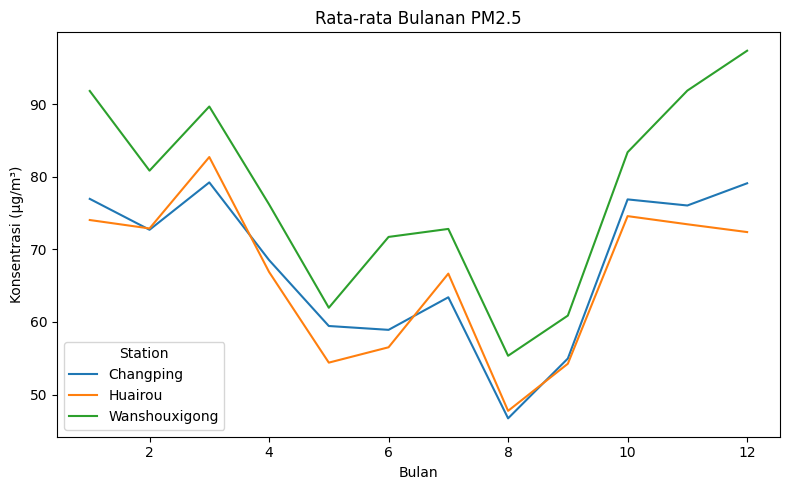

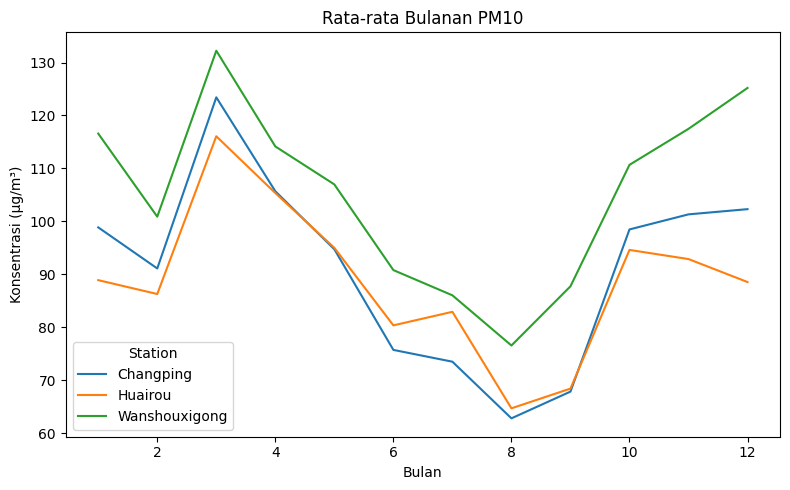

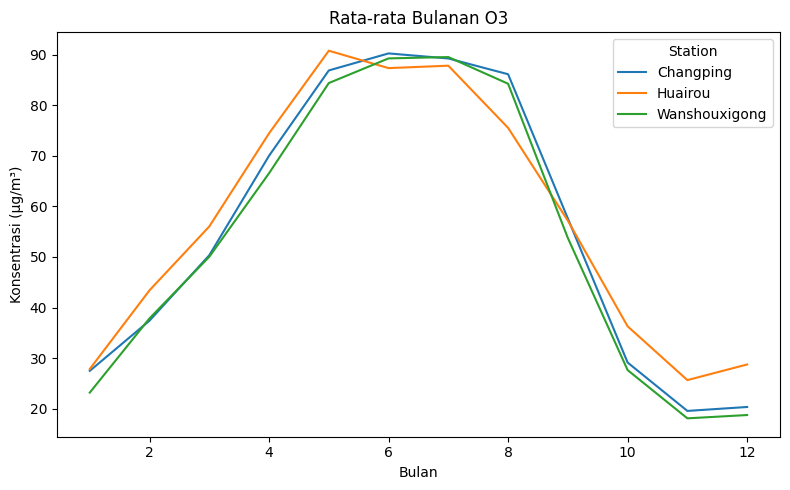

In [ ]:
#visualisasi pola bulanan
for polutan in visualisasi_bulanan['Polutan'].unique():
    # Filter data untuk polutan tertentu
    df_polutan = visualisasi_bulanan[visualisasi_bulanan['Polutan'] == polutan]

    # Plot lineplot untuk polutan ini
    plt.figure(figsize=(8,5))
    sns.lineplot(
        data=df_polutan,
        x='month', y='Konsentrasi', hue='station'
    )
    plt.title(f"Rata-rata Bulanan {polutan}")
    plt.xlabel("Bulan")
    plt.ylabel("Konsentrasi (μg/m³)")
    plt.legend(title='Station')
    plt.tight_layout()
    plt.show()

### Pertanyaan 2: Bagaimana pola diurnal polutan PM2.5, PM10, dan O3 di wilayah urban (Wanshouxigong), sub-urban (Changping), dan rural (Huariou)?

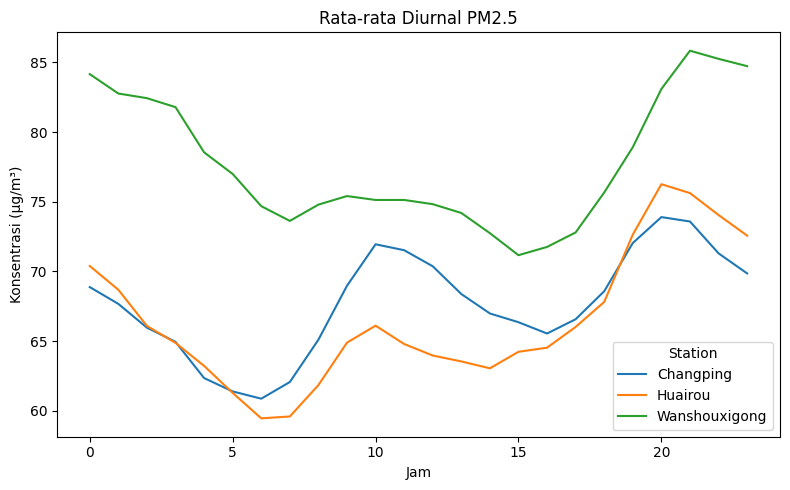

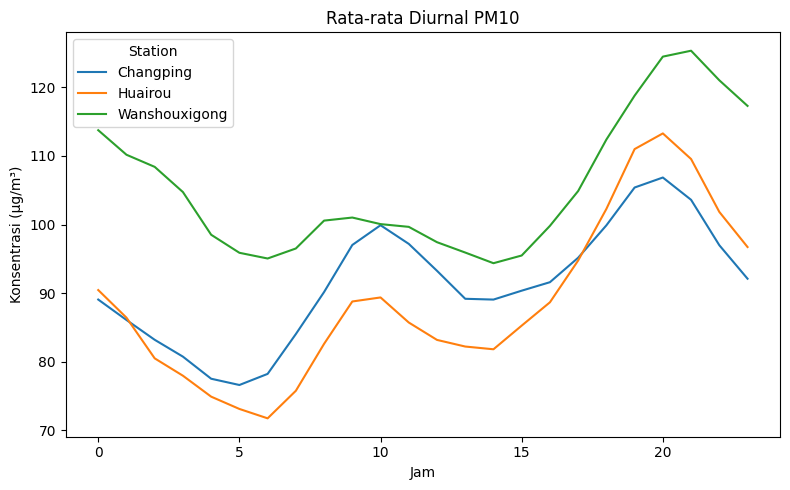

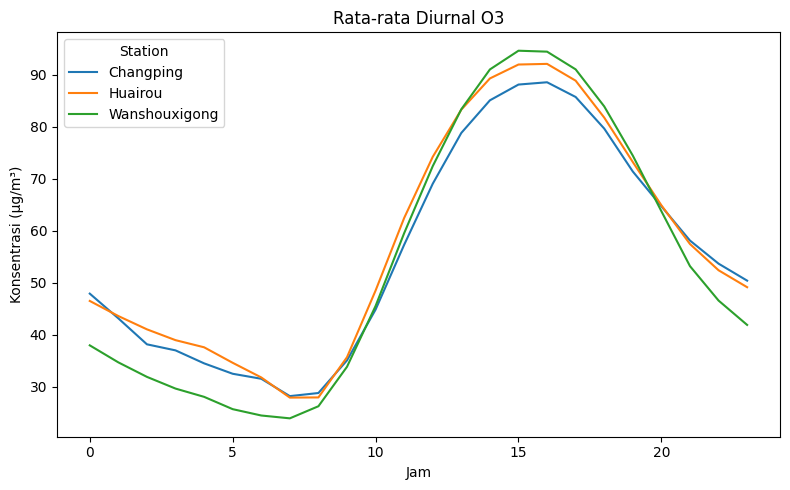

In [ ]:
for polutan in visualisasi_diurnal['Polutan'].unique():
    # Filter data untuk polutan tertentu
    df_polutan = visualisasi_diurnal[visualisasi_diurnal['Polutan'] == polutan]

    # Plot lineplot untuk polutan ini
    plt.figure(figsize=(8,5))
    sns.lineplot(
        data=df_polutan,
        x='hour', y='Konsentrasi', hue='station'
    )
    plt.title(f"Rata-rata Diurnal {polutan}")
    plt.xlabel("Jam")
    plt.ylabel("Konsentrasi (μg/m³)")
    plt.legend(title='Station')
    plt.tight_layout()
    plt.show()

### Pertanyaann 3: Apakah konsentrasi polutan PM2.5 dan PM10 di atas BMUA harian (24 jam) untuk wilayah urban (Wanshouxigong), sub-urban (Changping), dan rural (Huariou)?

Text(0, 0.5, 'Konsentrasi (μg/m³)')

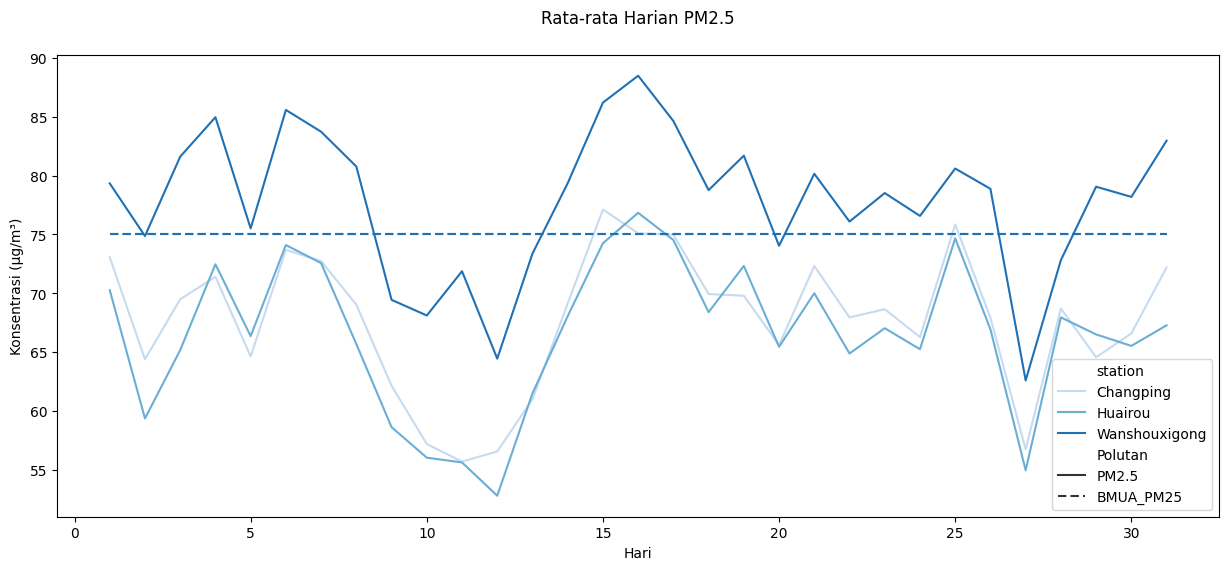

In [ ]:
#plot line harian PM10
plt.figure(figsize=(15, 6))
line_PM25 = sns.lineplot(
    data=vis_PM25,
    x='day', y='Konsentrasi (μg/m³)',
    hue='station', style='Polutan',
    style_order=['PM2.5', 'BMUA_PM25'],  # Tentukan urutan style
    dashes={'PM2.5': '', 'BMUA_PM25': (4, 2)},  # Solid untuk PM2.5, putus-putus untuk BMUA
    palette='Blues'
)

#judul plot
line_PM25.set_title("Rata-rata Harian PM2.5", y=1.05)

#nama sumbu x
line_PM25.set_xlabel("Hari")

#nama sumbu y
line_PM25.set_ylabel("Konsentrasi (μg/m³)")

Text(0, 0.5, 'Konsentrasi (μg/m³)')

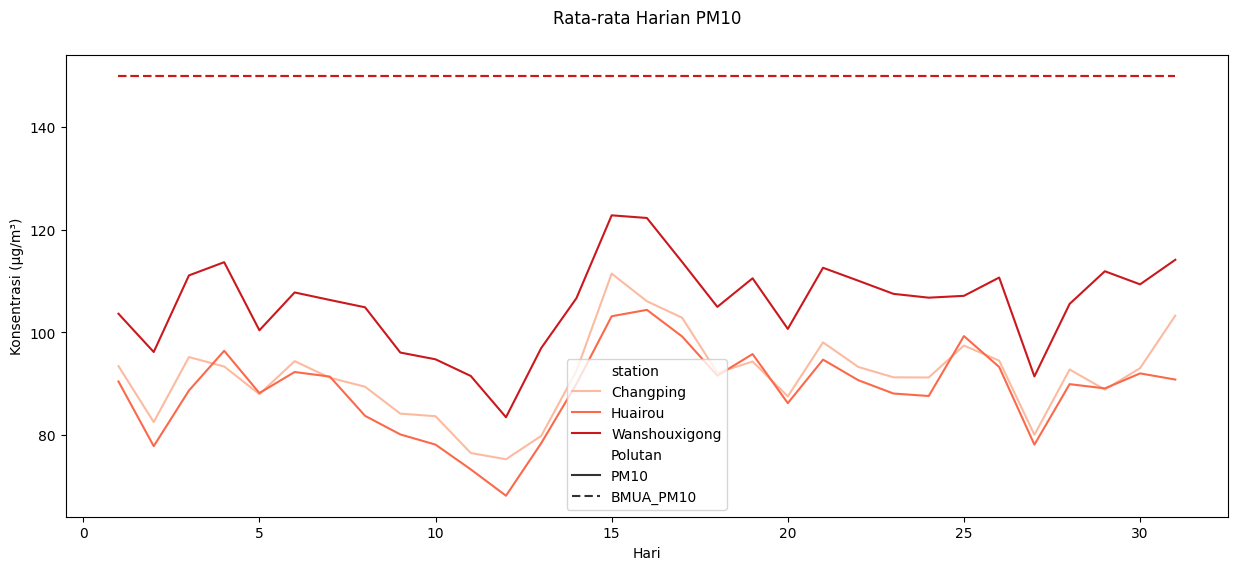

In [ ]:
#plot line harian PM10
plt.figure(figsize=(15, 6))
line_PM10 = sns.lineplot(
    data=vis_PM10,
    x='day', y='Konsentrasi (μg/m³)',
    hue='station', style='Polutan',
    style_order=['PM10', 'BMUA_PM10'],
    dashes={'PM10': '', 'BMUA_PM10': (4, 2)},  # Solid untuk PM10, putus-putus untuk BMUA
    palette='Reds'
)

#judul plot
line_PM10.set_title("Rata-rata Harian PM10", y=1.05)

#nama sumbu x
line_PM10.set_xlabel("Hari")

#nama sumbu y
line_PM10.set_ylabel("Konsentrasi (μg/m³)")

**Insight:**
- Pola bulanan PM2.5 dan PM10 menunjukkan dua puncak konsentrasi, yaitu pada awal dan akhir tahun dengan nilai terendah di pertengahan tahun. Pola ini dipengaruhi sudut deklinasi matahari dan musiman. Sebaliknya, konsentrasi O₃ mencapai puncaknya saat PM menurun, mengikuti pola yang berlawanan. Ozon troposfer semakin banyak pada musim kering (Juni-Juli-Agustus) akibat meningkatnya radiasi matahari dan suhu yang mempercepat reaksi fotokimia antara nitrogen oksida (NOₓ) dan senyawa organik volatil (VOC), sehingga menghasilkan O₃ dalam jumlah lebih tinggi.
- Pola diurnal PM2.5 dan PM10 menunjukkan puncak konsentrasi di pagi dan malam hari dengan pola cenderung konstan. Pola yang konstan menandakan kecenderungan aktivitas penghasil polusi yang sama disetiap waktu. Sementara itu, puncak konsentrasi O₃ di siang hari. Pola ini menunjukkan bahwa konsentrasi O₃ meningkat seiring dengan meningkatnya suhu dan radiasi matahari dengan lag time sekitar 4 jam dari waktu puncak radiasi matahari pada umumnya.
- Konsentrasi harian PM2.5 menunjukkan wilayah urban (Wanshouxigong) terkonsentrasi di atas BMUA, sedangkan sub-urban dan urban cenderung di bawah nilai BMUA. Nilai di atas BMUA menandakan pencemaran udara yang tinggi. Sementara itu, konsentrasi harian PM10 menunjukkan nilai di bawah standar BMU di seluruh stasiun. Nilai standar BMUA diambil berdasarkan Air Quality Standards China dalam nilai Grade II (wilayah kota industrial maupun rural yang tidak dipantau khusus).

## Analisis Lanjutan: Clustering-based Binning

### Pertanyaan 4: Bagaimana kategori data rata-rata bulanan di wilayah urban (Wanshouxigong), suburban (Changping), dan rural (Huariou)?

In [ ]:
#kategori nilai
cat_PM25 = pd.cut(Pola_bulanan['PM2.5'], bins=3, labels=['Low', 'Medium', 'High'])
cat_PM10 = pd.cut(Pola_bulanan['PM10'], bins=3, labels=['Low', 'Medium', 'High'])
cat_O3 = pd.cut(Pola_bulanan['O3'], bins=3, labels=['Low', 'Medium', 'High'])

#pembuatan list data
table_PM25 = [(stasiun, bulan, nilai, kategori) for stasiun, bulan, nilai, kategori in zip(Pola_bulanan['station'],Pola_bulanan['month'], Pola_bulanan['PM2.5'], cat_PM25)]
table_PM10 = [(stasiun, bulan, nilai, kategori) for stasiun, bulan, nilai, kategori in zip(Pola_bulanan['station'],Pola_bulanan['month'], Pola_bulanan['PM10'], cat_PM10)]
table_O3 = [(stasiun, bulan, nilai, kategori) for stasiun, bulan, nilai, kategori in zip(Pola_bulanan['station'],Pola_bulanan['month'], Pola_bulanan['O3'], cat_O3)]

#pembuatan dataframe
df_table_PM25 = pd.DataFrame(table_PM25, columns=['Stasiun','Bulan', 'PM2.5', 'Kategori PM2.5'])
df_table_PM10 = pd.DataFrame(table_PM10, columns=['Stasiun','Bulan', 'PM10', 'Kategori PM10'])
df_table_O3 = pd.DataFrame(table_O3, columns=['Stasiun','Bulan', 'O3', 'Kategori O3'])

#lihat hasil
print(df_table_PM25)
print(df_table_PM10)
print(df_table_O3)

          Stasiun  Bulan      PM2.5 Kategori PM2.5
0       Changping      1  76.940800         Medium
1       Changping      2  72.685963         Medium
2       Changping      3  79.206796         Medium
3       Changping      4  68.518565         Medium
4       Changping      5  59.437170            Low
5       Changping      6  58.907684            Low
6       Changping      7  63.391457            Low
7       Changping      8  46.724345            Low
8       Changping      9  54.964184            Low
9       Changping     10  76.868134         Medium
10      Changping     11  76.029748         Medium
11      Changping     12  79.087615         Medium
12        Huairou      1  74.029412         Medium
13        Huairou      2  72.868652         Medium
14        Huairou      3  82.698787           High
15        Huairou      4  66.883650         Medium
16        Huairou      5  54.394526            Low
17        Huairou      6  56.508795            Low
18        Huairou      7  66.64

In [ ]:
#penggabungan dalam satu tabel
cat_all = pd.concat([
    df_table_PM25[[col for  col in df_table_PM25.columns if col not in ['PM2.5']]],
    df_table_PM10[[col for col in df_table_PM10.columns if col not in ['Stasiun', 'Bulan', 'PM10']]],
    df_table_O3[[col for col in df_table_O3.columns if col not in ['Stasiun', 'Bulan', 'O3']]]],
    axis= 1)
print(cat_all)

          Stasiun  Bulan Kategori PM2.5 Kategori PM10 Kategori O3
0       Changping      1         Medium        Medium         Low
1       Changping      2         Medium        Medium         Low
2       Changping      3         Medium          High      Medium
3       Changping      4         Medium        Medium        High
4       Changping      5            Low        Medium        High
5       Changping      6            Low           Low        High
6       Changping      7            Low           Low        High
7       Changping      8            Low           Low        High
8       Changping      9            Low           Low      Medium
9       Changping     10         Medium        Medium         Low
10      Changping     11         Medium        Medium         Low
11      Changping     12         Medium        Medium         Low
12        Huairou      1         Medium        Medium         Low
13        Huairou      2         Medium        Medium      Medium
14        

In [ ]:
#group berdasarkan stasiun dan kategori nilai nya
cat_counts = cat_all.groupby('Stasiun')[['Kategori PM2.5', 'Kategori PM10', 'Kategori O3']].apply(
    lambda x: x.apply(pd.Series.value_counts).fillna(0).astype(int)
)
cat_counts.reset_index(inplace=True)

print(cat_counts)

         Stasiun level_1  Kategori PM2.5  Kategori PM10  Kategori O3
0      Changping    High               0              1            5
1      Changping     Low               5              4            5
2      Changping  Medium               7              7            2
3        Huairou    High               1              1            5
4        Huairou     Low               4              4            4
5        Huairou  Medium               7              7            3
6  Wanshouxigong    High               6              6            5
7  Wanshouxigong     Low               3              1            5
8  Wanshouxigong  Medium               3              5            2


In [ ]:
#data bantu visualisasi
vis_cat = cat_counts.melt(id_vars=['Stasiun','level_1'], value_vars=['Kategori PM2.5', 'Kategori PM10', 'Kategori O3'],
                          var_name='Keterangan', value_name='Jumlah')

vis_cat.columns =['Station', 'Kategori', 'Keterangan', 'Jumlah']
print(vis_cat)

          Station Kategori      Keterangan  Jumlah
0       Changping     High  Kategori PM2.5       0
1       Changping      Low  Kategori PM2.5       5
2       Changping   Medium  Kategori PM2.5       7
3         Huairou     High  Kategori PM2.5       1
4         Huairou      Low  Kategori PM2.5       4
5         Huairou   Medium  Kategori PM2.5       7
6   Wanshouxigong     High  Kategori PM2.5       6
7   Wanshouxigong      Low  Kategori PM2.5       3
8   Wanshouxigong   Medium  Kategori PM2.5       3
9       Changping     High   Kategori PM10       1
10      Changping      Low   Kategori PM10       4
11      Changping   Medium   Kategori PM10       7
12        Huairou     High   Kategori PM10       1
13        Huairou      Low   Kategori PM10       4
14        Huairou   Medium   Kategori PM10       7
15  Wanshouxigong     High   Kategori PM10       6
16  Wanshouxigong      Low   Kategori PM10       1
17  Wanshouxigong   Medium   Kategori PM10       5
18      Changping     High     

In [ ]:
#save data dalam csv

vis_cat.to_csv('vis_cat.csv', index=False)

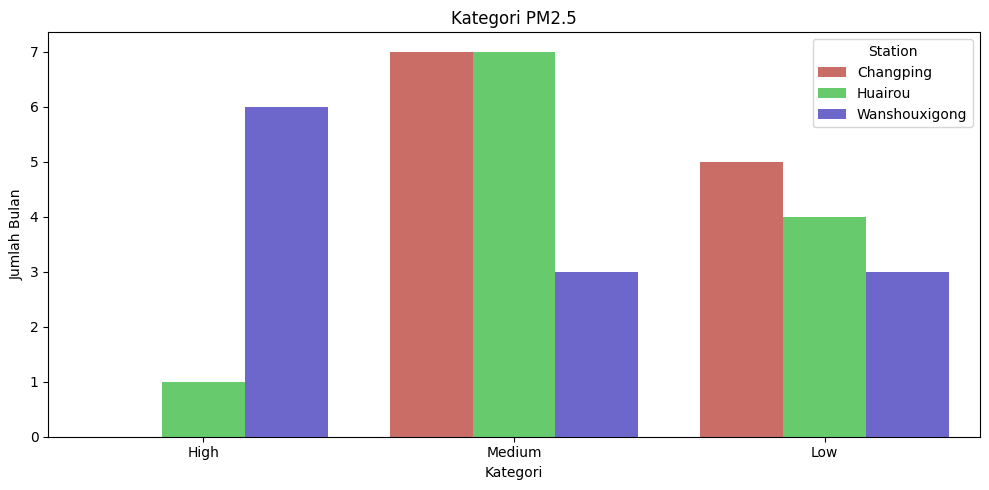

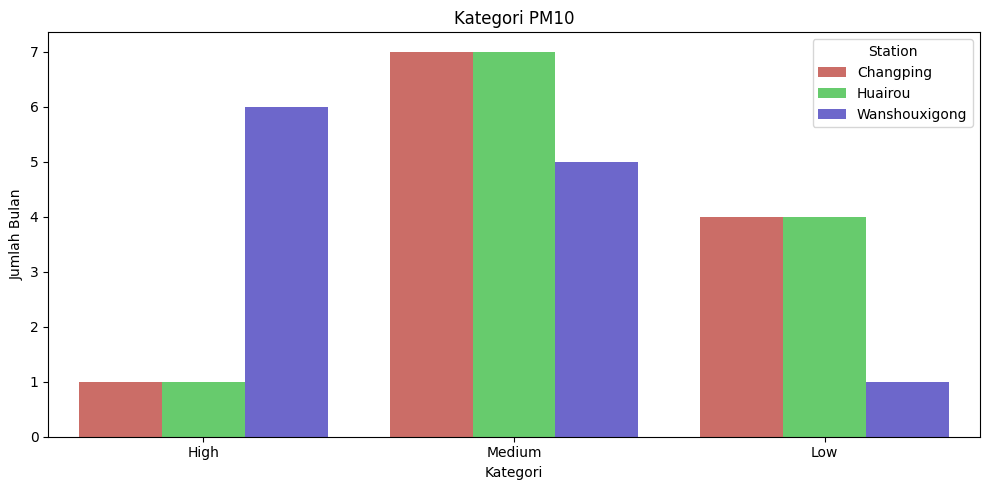

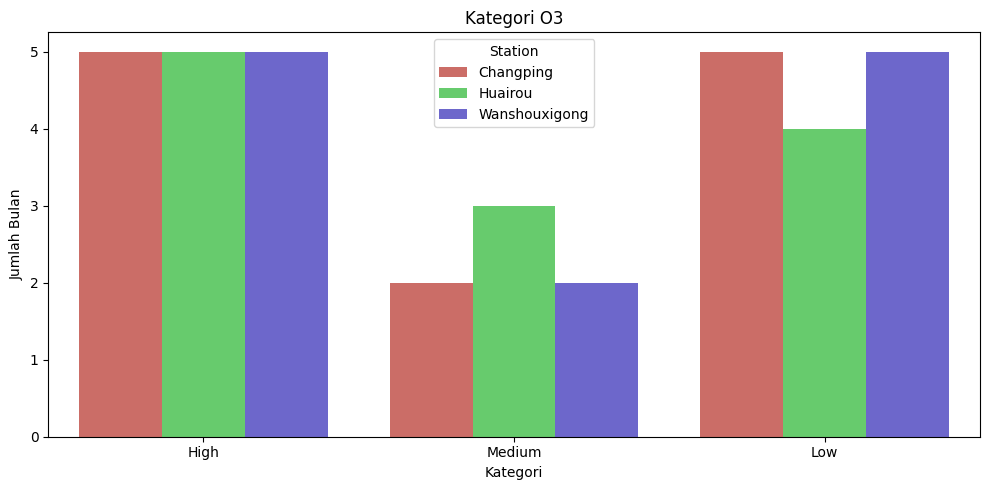

In [ ]:
#visualisasi data kategori
for keterangan in vis_cat['Keterangan'].unique():
    plt.figure(figsize=(10,5))
    barplot_cat = sns.barplot(
        data=vis_cat[vis_cat['Keterangan'] == keterangan],
        x='Kategori', y='Jumlah', hue='Station',
        palette='hls', errorbar= None,  order= ['High', 'Medium', 'Low']
    )
    plt.title(f"{keterangan}")
    plt.ylabel("Jumlah Bulan")
    plt.tight_layout()
    plt.show()

### insight:
Konsentrasi PM2.5 dan PM10 secara berturut-turut cenderung memiliki nilai lebih tinggi di wilayah urban (Wanshouxigong), suburban (Changping), dan rural (Huairou). Sementara itu, O₃ hampir sama diseluruh wilayah dengan kecenderungan sedikit lebih banyak di wilayah rural.

## Conclusion

1. Pola bulanan PM2.5 dan PM10 menunjukkan konsentrasi lebih banyak di awal dan akhir tahun, sedangkan polutan O₃ pada musim kering (Juni-Juli-Agustus).
2. Pola diurnal PM2.5 dan PM10 menunjukkan konsentrasi lebih banyak di malam hari dengan pola cenderung konstan, sedangkan O₃ puncak konsentrasinya di siang hari.
3. Konsentrasi harian PM2.5 menunjukkan wilayah urban berpolusi tinggi dengan konsentrasi di atas BMUA, sedangkan PM10 menunjukkan nilai di bawah BMUA di seluruh stasiun.
4. Konsentrasi PM2.5 dan PM10 secara berturut-turut cenderung memiliki nilai lebih tinggi di wilayah urban (Wanshouxigong), sedangkan O₃ lebih banyak di wilayah rural (Huariou).

